In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv("D:/ecommerce-customer-intelligence/data/processed/ecommerce_clean.csv")


In [9]:
#Section 1 : Customer Analysis

print("Total unique customers:", df['CustomerID'].nunique())

order_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()
print("Average Order Per Customer\n:")
print(order_per_customer.describe())

Total unique customers: 4338
Average Order Per Customer
:
count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


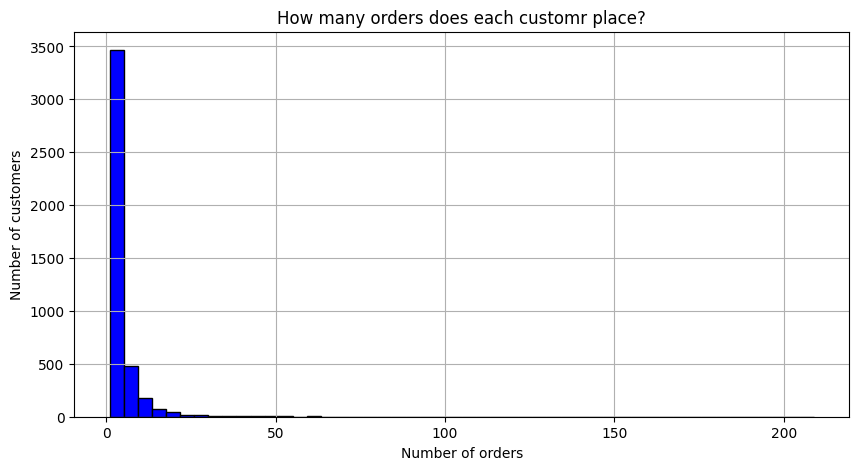

In [74]:
#VISULIZATION

plt.figure(figsize=(10,5))
order_per_customer.hist(bins=50, color="blue" , edgecolor="black")
plt.title('How many orders does each customr place?')
plt.xlabel("Number of orders")
plt.ylabel("Number of customers")
plt.savefig(r'D:\ecommerce-customer-intelligence\dashboards\Avg orders per customer.png')

plt.show()

**Observation:**
Order frequency is heavily right-skewed.
Most customers placed only 1-3 orders.
Very few customers are high-frequency buyers.

**Business Implication:**
One-time buyers represent the biggest churn
risk in this dataset.

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64


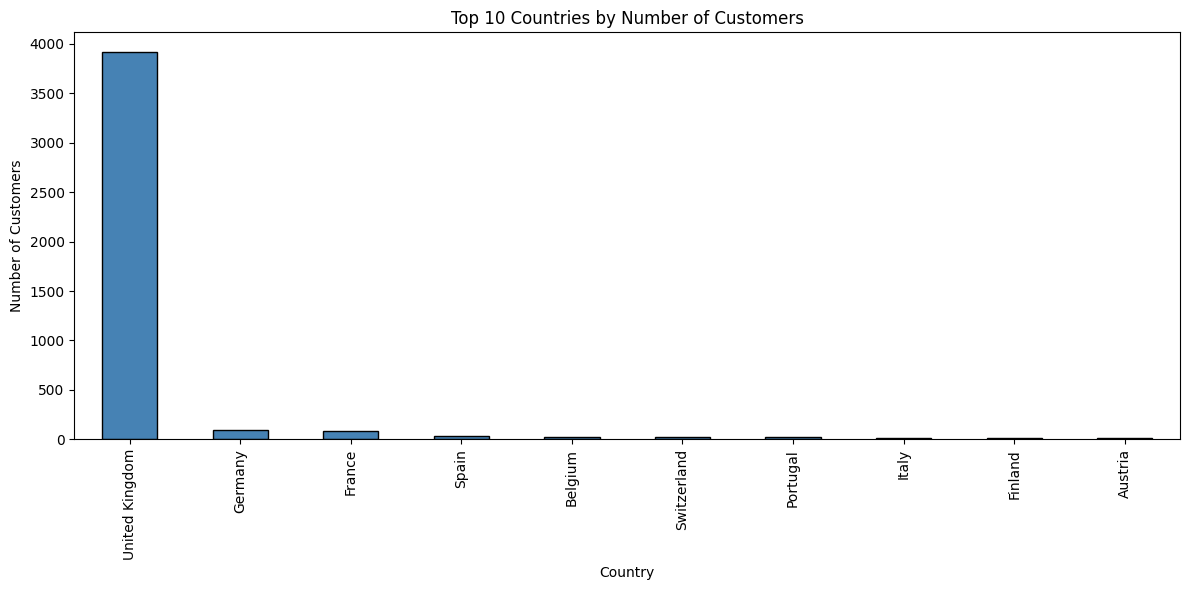

In [73]:
#Country Analysis 
# How many unique customers per country?
country_counts = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

print(country_counts.head(10))

plt.figure(figsize=(12,6))
country_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r'D:\ecommerce-customer-intelligence\dashboards\TopCountriesByRevenue.png')

plt.show()

In [36]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['TotalPrice'].sum()
print(monthly_revenue)

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: TotalPrice, dtype: float64


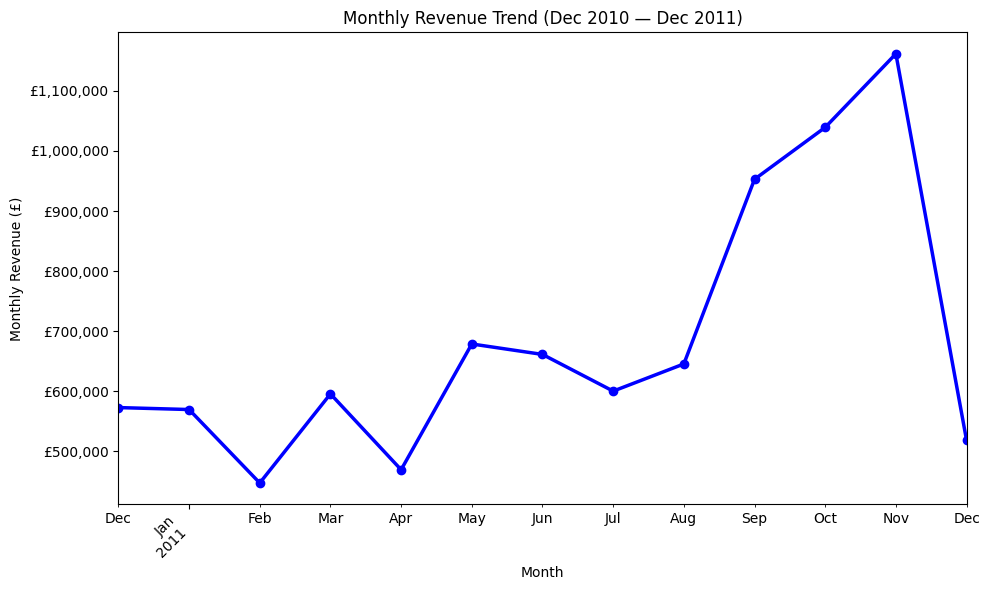

In [72]:
plt.figure(figsize=(10,6))
monthly_revenue.plot( kind= 'line',
                      color="Blue",
                        linewidth=2.5,
marker="o",
markersize=6)
plt.title('Monthly Revenue Trend (Dec 2010 — Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Monthly Revenue (£)')
plt.xticks(rotation=45 , ha='right')
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
plt.savefig(r'D:\ecommerce-customer-intelligence\dashboards\monthly_revenue_Trend.png')
plt.tight_layout()
plt.show()

## Observation 3 — Monthly Revenue Trend

- Overall revenue grew significantly from Dec 2010 to Nov 2011
- Sharp growth spike in Sep-Nov 2011 — likely holiday season stocking
- Feb and Apr 2011 show slight dips — post-holiday slowdown
- Dec 2011 appears low but dataset only covers 9 days of that month
- This is NOT a business decline — it is incomplete data

In [44]:
df['product']= df['Description']
top_products = df.groupby('product')['Quantity'].sum().sort_values(ascending=False)



product
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
RED  HARMONICA IN BOX                 20975
JUMBO BAG PINK POLKADOT               20165
SMALL POPCORN HOLDER                  18252
LUNCH BAG RED RETROSPOT               17697
60 TEATIME FAIRY CAKE CASES           17689
Name: Quantity, dtype: int64


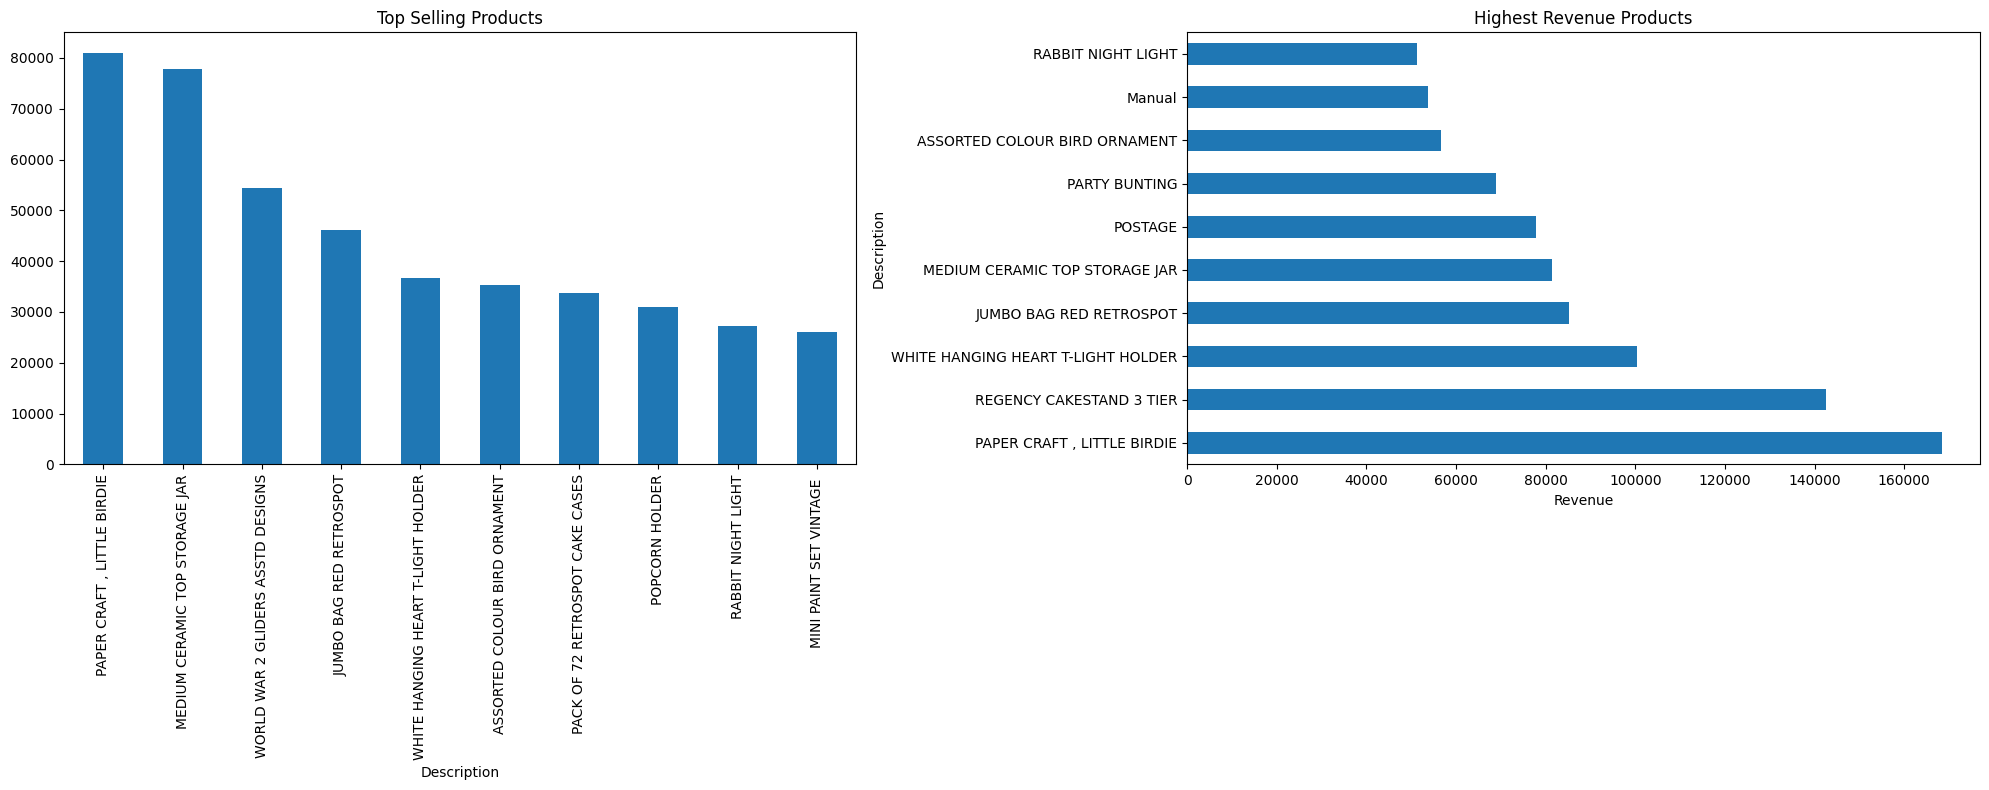

In [71]:
import matplotlib.pyplot as plt

# Create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Top selling products
top_selling = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Highest revenue products
top_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

# ubplots
fig, axes = plt.subplots(1, 2, figsize=(20,8))

# Plot top selling
top_selling.plot(kind='bar', ax=axes[0])
axes[0].set_title('Top Selling Products')


# Plot top revenue
top_revenue.plot(kind='barh', ax=axes[1])
axes[1].set_title('Highest Revenue Products')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.savefig(r'D:\ecommerce-customer-intelligence\dashboards\product_analysis.png')
plt.show()

## Observations from Product Analysis

### Top Selling Products
- PAPER CRAFT , LITTLE BIRDIE is the highest-selling product based on quantity sold.
- MEDIUM CERAMIC TOP STORAGE JAR is the second most purchased product.
- Products such as WORLD WAR 2 GLIDERS ASSTD DESIGNS and JUMBO BAG RED RETROSPOT also show strong customer demand.
- The sales distribution indicates that a small number of products contribute significantly to total sales volume.

### Highest Revenue Products
- PAPER CRAFT , LITTLE BIRDIE generates the highest revenue among all products.
- REGENCY CAKESTAND 3 TIER contributes high revenue despite lower sales quantity, suggesting a higher unit price.
- WHITE HANGING HEART T-LIGHT HOLDER performs strongly in both quantity sold and revenue generation.
- POSTAGE appearing among top revenue contributors indicates shipping charges contribute significantly to overall revenue.

### Business Insights
- High sales quantity does not always mean high revenue.
- Premium-priced products can generate high revenue with fewer sales.
- Products performing well in both charts should be prioritized for inventory management and marketing.
- The analysis follows the Pareto Principle, where a small percentage of products contribute a large portion of total revenue and sales.m